In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

T          = 1000       
batch_size = 64
lr         = 2e-4
epochs     = 10
img_size   = 28

In [4]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  
])

dataset = datasets.MNIST(root="./data", transform=transform, download=True)
loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 43.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.66MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.73MB/s]


In [5]:

betas      = torch.linspace(1e-4, 0.02, T).to(device)          
alphas     = 1.0 - betas                                         
alpha_bar  = torch.cumprod(alphas, dim=0)                       

# Pre-compute useful quantities
sqrt_ab    = torch.sqrt(alpha_bar)                              
sqrt_1mab  = torch.sqrt(1.0 - alpha_bar)                     

def get(arr, t, shape):

    return arr[t].reshape(shape[0], *([1]*(len(shape)-1)))

In [6]:

def q_sample(x0, t):
    eps   = torch.randn_like(x0)
    s_ab  = get(sqrt_ab,   t, x0.shape)
    s_1ab = get(sqrt_1mab, t, x0.shape)
    return s_ab * x0 + s_1ab * eps, eps   

In [7]:


class SinusoidalPE(nn.Module):

    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        emb  = math.log(10000) / (half - 1)
        emb  = torch.exp(torch.arange(half, device=t.device) * -emb)
        emb  = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)   # (B, dim)


class ResBlock(nn.Module):

    def __init__(self, ch, t_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, ch)
        self.conv1 = nn.Conv2d(ch, ch, 3, padding=1)
        self.t_proj = nn.Linear(t_dim, ch)          
        self.norm2 = nn.GroupNorm(8, ch)
        self.conv2 = nn.Conv2d(ch, ch, 3, padding=1)

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.t_proj(F.silu(t_emb))[:, :, None, None]  
        h = self.conv2(F.silu(self.norm2(h)))
        return x + h


class UNet(nn.Module):

    def __init__(self, ch=64, t_dim=128):
        super().__init__()
        self.t_emb = nn.Sequential(
            SinusoidalPE(t_dim),
            nn.Linear(t_dim, t_dim * 4),
            nn.SiLU(),
            nn.Linear(t_dim * 4, t_dim)
        )
        td = t_dim

        # Encoder
        self.enc0   = nn.Conv2d(1, ch, 3, padding=1)          
        self.res0   = ResBlock(ch, td)
        self.down1  = nn.Conv2d(ch, ch*2, 4, 2, 1)           
        self.res1   = ResBlock(ch*2, td)
        self.down2  = nn.Conv2d(ch*2, ch*4, 4, 2, 1)          
        self.res2   = ResBlock(ch*4, td)

        # Bottleneck
        self.mid    = ResBlock(ch*4, td)

        # Decoder (skip connections)
        self.up1    = nn.ConvTranspose2d(ch*4, ch*2, 4, 2, 1) 
        self.res3   = ResBlock(ch*4, td)                      
        self.up2    = nn.ConvTranspose2d(ch*4, ch,   4, 2, 1)
        self.res4   = ResBlock(ch*2, td)                       

        # Output head
        self.out    = nn.Sequential(
            nn.GroupNorm(8, ch*2),
            nn.SiLU(),
            nn.Conv2d(ch*2, 1, 1)                              
        )

    def forward(self, x, t):
        te = self.t_emb(t)                          

        # Encoder
        x0 = self.res0(self.enc0(x), te)            
        x1 = self.res1(self.down1(x0), te)          
        x2 = self.res2(self.down2(x1), te)          

        # Bottleneck
        h  = self.mid(x2, te)                      

        
        h  = self.res3(torch.cat([self.up1(h), x1], 1), te)  
        h  = self.res4(torch.cat([self.up2(h), x0], 1), te)   

        return self.out(h)                         


model = UNet().to(device)
opt   = torch.optim.Adam(model.parameters(), lr=lr)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 5,924,481


In [8]:


for epoch in range(epochs):
    total_loss = 0
    for x0, _ in loader:                          
        x0 = x0.to(device)
        B  = x0.size(0)

        t       = torch.randint(0, T, (B,), device=device) 
        xt, eps = q_sample(x0, t)                            
        eps_hat = model(xt, t)                              

        loss = F.mse_loss(eps_hat, eps)                     

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1:02d}: loss={total_loss/len(loader):.4f}")

Epoch 01: loss=0.0497
Epoch 02: loss=0.0286
Epoch 03: loss=0.0262
Epoch 04: loss=0.0253
Epoch 05: loss=0.0246
Epoch 06: loss=0.0242
Epoch 07: loss=0.0238
Epoch 08: loss=0.0236
Epoch 09: loss=0.0234
Epoch 10: loss=0.0232


In [9]:


@torch.no_grad()
def sample(n=16):
    model.eval()
    x = torch.randn(n, 1, img_size, img_size, device=device)  # xT

    for t_val in reversed(range(T)):
        t_batch = torch.full((n,), t_val, device=device, dtype=torch.long)

        beta_t  = betas[t_val]
        a_t     = alphas[t_val]
        ab_t    = alpha_bar[t_val]

        eps_hat = model(x, t_batch)
        x = (1 / a_t.sqrt()) * (x - (beta_t / (1 - ab_t).sqrt()) * eps_hat)

        if t_val > 0:                                          
            z = torch.randn_like(x)
            x = x + beta_t.sqrt() * z

    model.train()
    return x.clamp(-1, 1)


samples = sample(n=16)

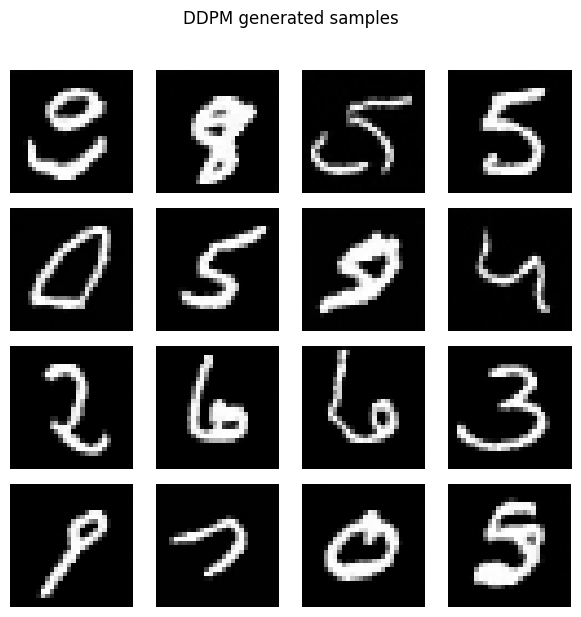

In [10]:

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    img = samples[i, 0].cpu()
    ax.imshow(img, cmap='gray', vmin=-1, vmax=1)
    ax.axis('off')
plt.suptitle('DDPM generated samples', y=1.02)
plt.tight_layout()
plt.show()